# 05 — The refugia complexes (run spec v3 §1a, revised 2026-09-29; zero routing)

Derives the refugia COMPLEXES from `v2_run001` and writes the AUDIT OBJECTS the engine's contraction loader reads. The v2
patch-to-patch links are used ONLY here, to derive the complexes and the within-complex sliver table; they are not reported.

1. Complexes = connected components of the 130 near-contiguous (D25) links; `complex_id` on every node; dissolved polygons;
   single patches are complexes. Checks: every patch in exactly one complex; complex areas = the patch total.
2. The v2 corridor-class links with both ends in one complex (three β-backups) join the sliver table.
3. Sliver table: one row per within-complex link (patches, path length, cost-10 / 100 / 1000 cells along the centreline).
4. Names (D-W7): patches 'Refugium (Sustut)', complexes 'Refugia complex (Nahanni)' (the six Nááts'Ihch'Oh variants fall
   under it); `display_name` filled in the tracked `audit/audit_objects/node_names.csv`; rename complexes in
   `audit/audit_objects/complex_names.csv` (`display_name`).
5. **CHECK STOP 3**: the complex map — a complex that splits where one range is expected is RECORDED, not acted on.

Then COMMIT the audit objects (`complex_membership.csv`, `complex_names.csv`, `complexes.gpkg`, `slivers_v2.csv`,
`complexes_summary.json`, `node_names.csv`) — 06 builds the run record on a clean tree.

In [1]:
# ---- Setup: find the project root, import the shared engines ----------------
# This notebook lives in analyses/wolverine_refugia_connectivity/, below the repo root where
# config.py and the corridor engine modules sit. Same bootstrap as analyses/northern_connectivity/.
import sys, pathlib, json
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import numpy as np
import pandas as pd
import config
import corridors_prep as cp
import corridor_graph as cg
import corridors_core as cc
for _m in (config, cp, cg, cc):
    importlib.reload(_m)

KEY = "wolverine"
CFG = config.CORRIDORS[KEY]
HERE = ROOT / "analyses" / "wolverine_refugia_connectivity"

import matplotlib.pyplot as plt
import corridors_mapstyle as ms
import corridors_director as cd
import director_core as dc
import wolverine_director as wd
for _m in (ms, cd, dc, wd):
    importlib.reload(_m)

import wolverine_postprocess as wp
importlib.reload(wp)
FROM = CFG["v25"]["from_run"]
P0 = wp.load(config.RESULTS_DIR / CFG["results_subdir"] / FROM)

v2_run001: results context loaded (170 edges, 44 branches, corridor 52,572 km²)
v2_run001: 130 patches, 170 links = 130 near-contiguous + 40 corridor links (+ 0 adjacency/zero-cost) | cutoff 13.6230 = 4.09 km detour


## 1 · Complexes · 2 · the v2 corridor-class links (within-complex ones -> the sliver table) · 3 · Slivers · 4 · Names

In [2]:
mem, cx = wp.complexes(P0)
links = wp.corridor_links(P0)                # v2 links: only the within-complex ones are kept (sliver table); nothing else is reported
sl = wp.slivers(P0)
nd, cn = wp.rename(P0, audit_names_path=HERE / "audit" / "audit_objects" / "node_names.csv", write_audit=True)
P0.force = False                             # True only to discard display names already filled in complex_names.csv
summ = wp.write_audit(P0)
cx = wp.write(P0)
display(cx.drop(columns="geometry")[["complex_id", "name", "n_patches", "area_km2", "largest_patch_name", "n_slivers", "n_slivers_with_feature", "lat"]])

complexes: 23 (15 single-patch; most patches Refugia complex (Sustut, E) 43; largest Refugia complex (Jasper) 135,778 km²) from 130 near-contiguous links; complex land = patch total 282,996 km²
corridor-class links: 40 = 37 INTER-complex (between 27 complex pairs; pairs joined by more than one link: 10 -> {'C1-C2': 2, 'C2-C6': 2, 'C4-C7': 2, 'C5-C7': 2, 'C7-C9': 2, 'C12-C20': 2, 'C14-C20': 2, 'C19-C20': 2, 'C20-C21': 2, 'C18-C23': 2}) + 3 WITHIN one complex (E034_039: C7 securing, E102_105: C12 squeezed, E112_113: C20 squeezed) -- listed with the slivers, not mapped
slivers: 133 within-complex links; 62 with a cost-100/1000 cell on the path; 43 touch cost 10; path length median 3.9 km, max 33.9
audit node_names.csv: display_name filled for 130 patches (the run-dir copy stays pinned)
names: 130 patches renamed as refugia; 14 display names shared by several patches (e.g. {'Refugium (Nááts’Ihch’Oh)': np.int64(6), 'Refugium (Spatsizi Plateau)': np.int64(6), 'Refugium (Nahanni)': np.int64(4

,complex_id,name,n_patches,area_km2,largest_patch_name,n_slivers,n_slivers_with_feature,lat
0,1,Refugia complex (Nahanni),20,20657.3,Nahanni National Park Reserve Of Canada,21,9,62.5421
1,2,Refugium (Nahanni),1,285.6,Nahanni National Park Reserve Of Canada,0,0,60.9573
2,3,"Refugium (Boya Lake, W)",1,292.1,Boya Lake Park (W),0,0,59.3539
3,4,"Refugium (Stikine River, NW)",1,743.1,Stikine River Park (NW),0,0,58.4044
4,5,"Refugia complex (Stikine River, NW)",2,856.5,Stikine River Park (NW),1,1,58.2176
5,6,Refugia complex (Northern Rocky Mountains),10,14859.6,Northern Rocky Mountains Park,9,3,57.9038
6,7,"Refugia complex (Sustut, E)",43,29569.6,Sustut Park (E),59,21,57.1505
7,8,Refugium (Sustut),1,279.2,Sustut Park,0,0,56.1673
8,9,Refugium (Omineca),1,382.2,Omineca Park,0,0,55.8017
9,10,"Refugium (Babine River, E)",1,456.6,Babine River Corridor Park (E),0,0,55.6323


## CHECK STOP 3 — the complexes

Look for a complex that splits where one range is expected (the D25 rule slightly tight for a wide-front pair) — record it in
`spec/results_log.md`, do not act on it. Rename complexes in `audit/audit_objects/complex_names.csv` (`display_name`) and re-run this
cell to see the labels; the engine loads the complexes from these files.

Y2Y — wolverine climate refugia: routing grid 4285x11038 @ 300 m = 17,240,740 routable cells (1,551,667 km²) -- whole window
  core refugia 318,822 km² in 1,845 8-connected patches; marginal 169,988 km²
    >=   100 km²:  239 patches holding  94.2% of core area
    >=   250 km²:  130 patches holding  88.8% of core area   <- node floor
    >=   500 km²:   67 patches holding  81.7% of core area
    >=  1000 km²:   36 patches holding  75.0% of core area
  node_names.csv applied: 130 display names overridden
  protected land (status layer, W11): existing PAs 201,672 km², proposed 179,528 km² | 43.5% of node land is protected
nodes: 130 core refugia patches >= 250 km² (282,996 km² of node land, numbered north -> south) | largest 78,454 km², smallest 254 km²
GW5 OK: 130 patches -> 23 complexes (8 multi-patch), membership sha cdd305f952e7


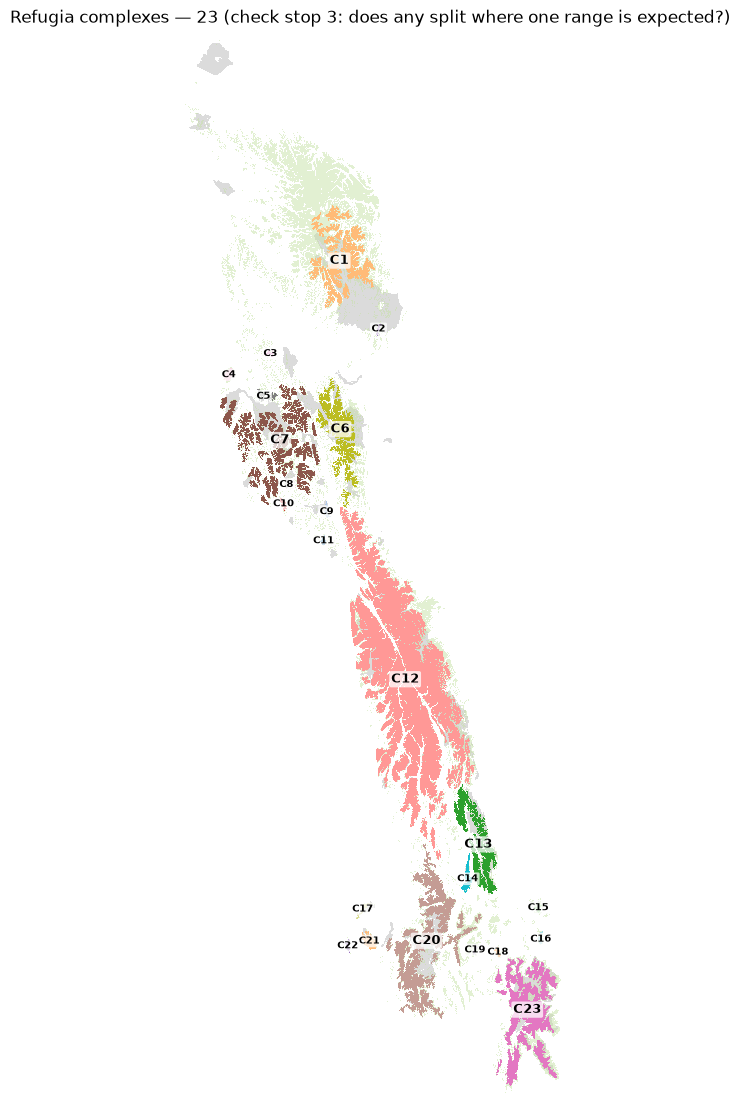

3740

In [3]:
cfg_v25, cost_path = cc.resolve(KEY, overrides=cc._merge(CFG["variants"][CFG["headline_variant"]], CFG["v25"]["overrides"]))
A0 = cc._raster_nodes(cfg_v25, cost_path, names_path=HERE / "audit" / "audit_objects" / "node_names.csv")
cc._contract_complexes(A0, HERE / "audit" / "audit_objects" / "complex_membership.csv", HERE / "audit" / "audit_objects" / "complex_names.csv")
cc.complex_map(A0, save=HERE / "figures" / "check_stop_3_complexes.png")
del A0; import gc; gc.collect()

## Done — commit the audit objects, then run `06_v25_network.ipynb` (the routing between the complexes, ~1 h).